In [1]:
import sys
print(sys.executable)

/Users/lahouimel/Documents/market-risk-var/.venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
tickers = ["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL"]

weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])

portfolio_value = 100000

In [4]:
print("Tickers :", tickers)
print("Somme des poids :", weights.sum())
print("Valeur du portefeuille :", portfolio_value, "€")

Tickers : ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL']
Somme des poids : 1.0
Valeur du portefeuille : 100000 €


In [5]:
googl = yf.download(
    "GOOGL",
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

googl.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2021-01-04,85.492973,87.293830,84.552422,87.170507,37324000
2021-01-05,86.182419,86.518220,85.035828,85.441468,20360000
2021-01-06,85.331993,86.376558,84.005618,84.211657,46588000
2021-01-07,87.880760,88.053116,85.524179,85.524179,41936000
2021-01-08,89.044174,89.119953,87.230923,88.020415,35484000


In [6]:
data = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                \
Ticker            AAPL        AMZN      GOOGL        MSFT       NVDA   
Date                                                                   
2021-01-04  125.632492  159.331497  85.492973  207.565353  13.046198   
2021-01-05  127.185799  160.925507  86.182419  207.765610  13.335950   
2021-01-06  122.904533  156.919006  85.331993  202.378403  12.549759   
2021-01-07  127.098404  158.108002  87.880760  208.137466  13.275514   
2021-01-08  128.195435  159.134995  89.044174  209.405579  13.208611   

Price             High                                                ...  \
Ticker            AAPL        AMZN      GOOGL        MSFT       NVDA  ...   
Date                                                                  ...   
2021-01-04  129.709890  163.600006  87.293830  212.628386  13.582432  ...   
2021-01-05  127.894501  161.169006  86.518220  208.356784  13.374501  ...   
2021-01-06  127.224642  159.875504  86.376558  206.421209  13.177023  ...   
2021-01-07  127.787685  160.427002  88.053116  209.138635  13.309091  ...   
2021-01-08  128.758506  159.531998  89.119953  210.320936  13.352120  ...   

Price             Open                                                \
Ticker            AAPL        AMZN      GOOGL        MSFT       NVDA   
Date                                                                   
2021-01-04  129.622521  163.500000  87.170507  212.180244  13.036996   
2021-01-05  125.127686  158.300507  85.441468  207.155376  13.032515   
2021-01-06  123.991843  157.324005  84.211657  202.302122  13.154638   
2021-01-07  124.613133  157.850006  85.524179  204.085131  12.900946   
2021-01-08  128.564332  159.000000  88.020415  208.509295  13.293921   

Price          Volume                                           
Ticker           AAPL      AMZN     GOOGL      MSFT       NVDA  
Date                                                            
2021-01-04  143301900  88228000  37324000  37130100  560640000  
2021-01-05   97664900  53110000  20360000  23823000  322760000  
2021-01-06  155088000  87896000  46588000  35930700  580424000  
2021-01-07  109578200  70290000  41936000  27694500  461480000  
2021-01-08  105158200  70754000  35484000  22956200  292528000  

[5 rows x 25 columns]

In [7]:
prices = data["Close"]

prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2021-01-04,125.632492,159.331497,85.492973,207.565353,13.046198
2021-01-05,127.185799,160.925507,86.182419,207.765610,13.335950
2021-01-06,122.904533,156.919006,85.331993,202.378403,12.549759
2021-01-07,127.098404,158.108002,87.880760,208.137466,13.275514
2021-01-08,128.195435,159.134995,89.044174,209.405579,13.208611


In [8]:
prices.isnull().sum()

Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64

In [9]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2021-01-05,0.012364,0.010004,0.008064,0.000965,0.022210
2021-01-06,-0.033662,-0.024897,-0.009868,-0.025929,-0.058953
2021-01-07,0.034123,0.007577,0.029869,0.028457,0.057830
2021-01-08,0.008631,0.006496,0.013239,0.006093,-0.005040
2021-01-11,-0.023249,-0.021519,-0.023106,-0.009698,0.025966


In [10]:
portfolio_returns = returns.dot(weights)

portfolio_returns.head()

Date
2021-01-05    0.010681
2021-01-06   -0.029345
2021-01-07    0.029342
2021-01-08    0.006587
2021-01-11   -0.013373
dtype: float64

In [11]:
portfolio_pnl = portfolio_returns * portfolio_value

portfolio_pnl.head()

Date
2021-01-05    1068.110468
2021-01-06   -2934.537873
2021-01-07    2934.185926
2021-01-08     658.738797
2021-01-11   -1337.302266
dtype: float64

In [12]:
confidence_level = 0.95

var_historical_return = np.percentile(
    portfolio_returns,
    (1 - confidence_level) * 100
)

var_historical_return

np.float64(-0.028810693679849713)

In [13]:
var_historical_eur = abs(var_historical_return * portfolio_value)

print(f"Historical VaR 95%: {var_historical_eur:.2f} €")

Historical VaR 95%: 2881.07 €


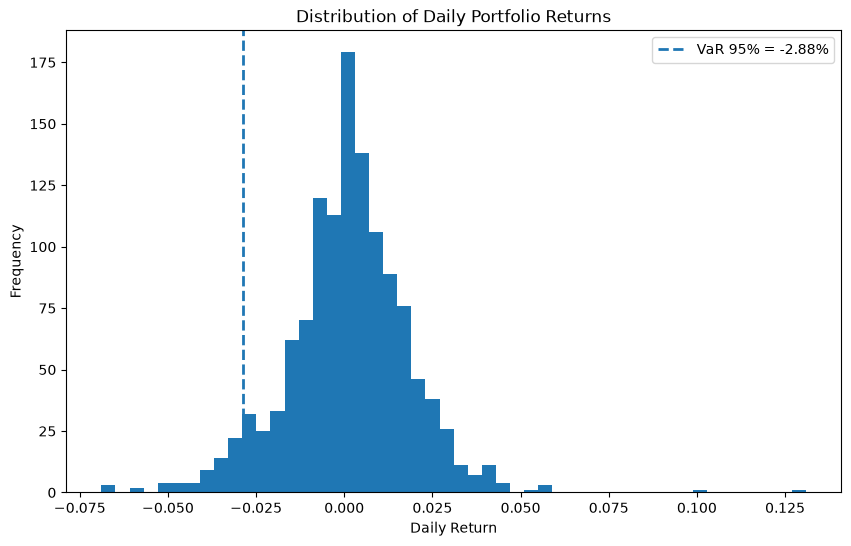

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(portfolio_returns, bins=50)

plt.axvline(
    var_historical_return,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% = {var_historical_return:.2%}"
)

plt.title("Distribution of Daily Portfolio Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [15]:
from scipy.stats import norm

In [16]:
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

z_score = norm.ppf(1 - confidence_level)

var_parametric_return = mean_return + z_score * std_return

var_parametric_eur = abs(var_parametric_return * portfolio_value)

print(f"Mean daily return: {mean_return:.4%}")
print(f"Daily volatility: {std_return:.4%}")
print(f"Parametric VaR 95%: {var_parametric_eur:.2f} €")

Mean daily return: 0.1090%
Daily volatility: 1.7360%
Parametric VaR 95%: 2746.39 €


In [17]:
np.random.seed(42)

n_simulations = 10000

simulated_returns = np.random.normal(
    mean_return,
    std_return,
    n_simulations
)

var_monte_carlo_return = np.percentile(
    simulated_returns,
    (1 - confidence_level) * 100
)

var_monte_carlo_eur = abs(
    var_monte_carlo_return * portfolio_value
)

print(f"Monte Carlo VaR 95%: {var_monte_carlo_eur:.2f} €")

Monte Carlo VaR 95%: 2763.76 €


In [18]:
var_comparison = pd.DataFrame({
    "Method": [
        "Historical",
        "Parametric",
        "Monte Carlo"
    ],
    "VaR 95% (€)": [
        var_historical_eur,
        var_parametric_eur,
        var_monte_carlo_eur
    ]
})

var_comparison

,Method,VaR 95% (€)
0,Historical,2881.069368
1,Parametric,2746.390389
2,Monte Carlo,2763.758129


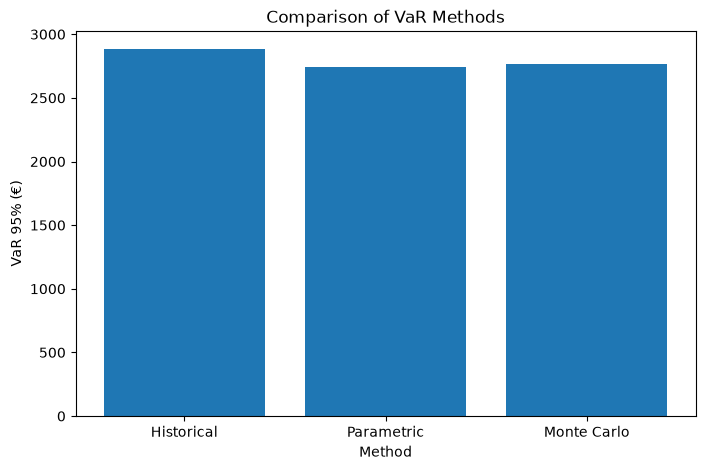

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    var_comparison["Method"],
    var_comparison["VaR 95% (€)"]
)

plt.title("Comparison of VaR Methods")
plt.xlabel("Method")
plt.ylabel("VaR 95% (€)")

plt.show()

In [20]:
var_threshold = -var_historical_eur

exceptions = portfolio_pnl[portfolio_pnl < var_threshold]

print("Nombre total de jours :", len(portfolio_pnl))
print("Nombre de dépassements :", len(exceptions))
print("Taux de dépassement :", f"{len(exceptions) / len(portfolio_pnl):.2%}")

Nombre total de jours : 1254
Nombre de dépassements : 63
Taux de dépassement : 5.02%


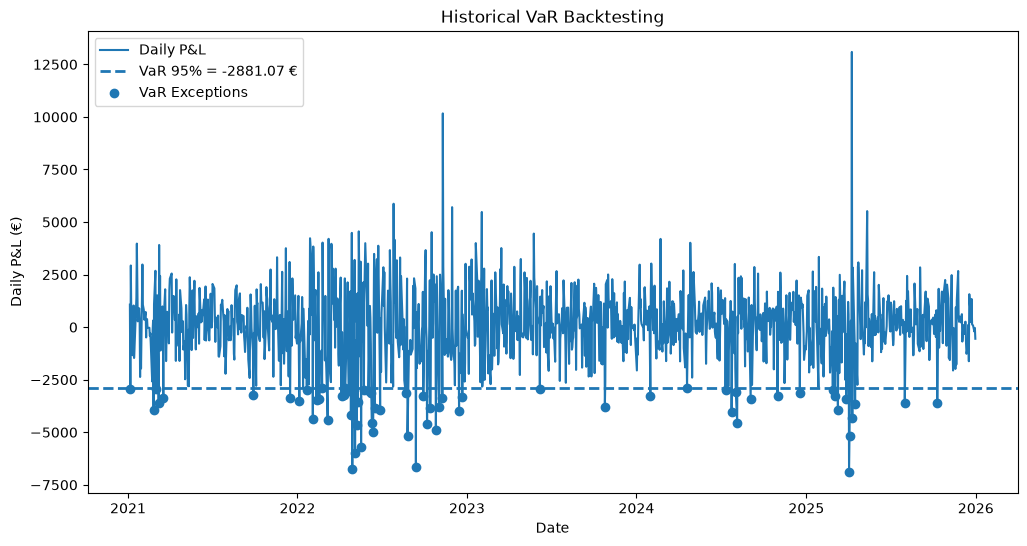

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_pnl.index,
    portfolio_pnl,
    label="Daily P&L"
)

plt.axhline(
    var_threshold,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% = -{var_historical_eur:.2f} €"
)

plt.scatter(
    exceptions.index,
    exceptions.values,
    label="VaR Exceptions"
)

plt.title("Historical VaR Backtesting")
plt.xlabel("Date")
plt.ylabel("Daily P&L (€)")
plt.legend()

plt.show()

In [22]:
from scipy.stats import chi2

In [23]:
n = len(portfolio_pnl)
x = len(exceptions)

p = 1 - confidence_level
observed_rate = x / n

lr_uc = -2 * (
    (n - x) * np.log((1 - p) / (1 - observed_rate))
    + x * np.log(p / observed_rate)
)

p_value = 1 - chi2.cdf(lr_uc, df=1)

print(f"Observed exception rate: {observed_rate:.2%}")
print(f"Kupiec LR statistic: {lr_uc:.4f}")
print(f"P-value: {p_value:.4f}")

Observed exception rate: 5.02%
Kupiec LR statistic: 0.0015
P-value: 0.9690


In [24]:
cvar_historical_return = portfolio_returns[
    portfolio_returns <= var_historical_return
].mean()

cvar_historical_eur = abs(
    cvar_historical_return * portfolio_value
)

print(f"Historical CVaR 95%: {cvar_historical_eur:.2f} €")

Historical CVaR 95%: 3850.46 €


In [25]:
summary = pd.DataFrame({
    "Metric": [
        "Historical VaR 95%",
        "Parametric VaR 95%",
        "Monte Carlo VaR 95%",
        "Historical CVaR 95%",
        "Backtesting Exception Rate"
    ],
    "Value": [
        f"{var_historical_eur:.2f} €",
        f"{var_parametric_eur:.2f} €",
        f"{var_monte_carlo_eur:.2f} €",
        f"{cvar_historical_eur:.2f} €",
        f"{len(exceptions) / len(portfolio_pnl):.2%}"
    ]
})

summary

,Metric,Value
0,Historical VaR 95%,2881.07 €
1,Parametric VaR 95%,2746.39 €
2,Monte Carlo VaR 95%,2763.76 €
3,Historical CVaR 95%,3850.46 €
4,Backtesting Exception Rate,5.02%


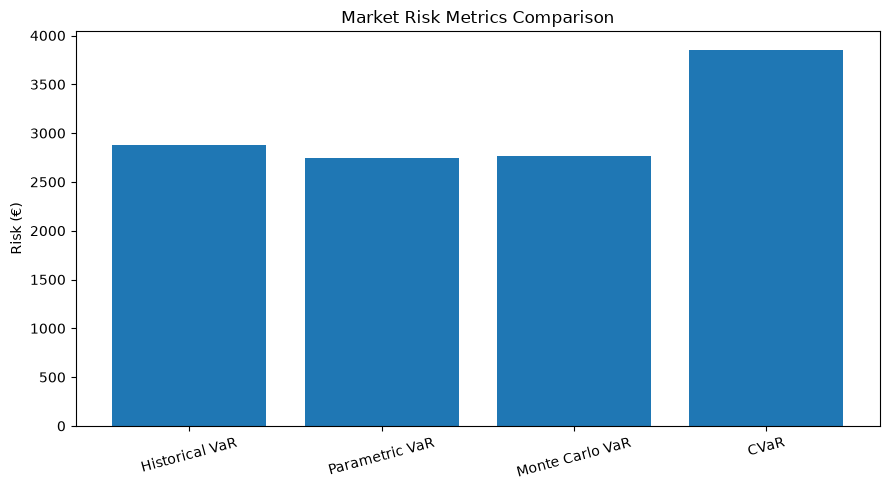

In [26]:
var_values = {
    "Historical VaR": var_historical_eur,
    "Parametric VaR": var_parametric_eur,
    "Monte Carlo VaR": var_monte_carlo_eur,
    "CVaR": cvar_historical_eur
}

plt.figure(figsize=(9, 5))
plt.bar(var_values.keys(), var_values.values())

plt.title("Market Risk Metrics Comparison")
plt.ylabel("Risk (€)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("../images/var_comparison.png", dpi=300)
plt.show()

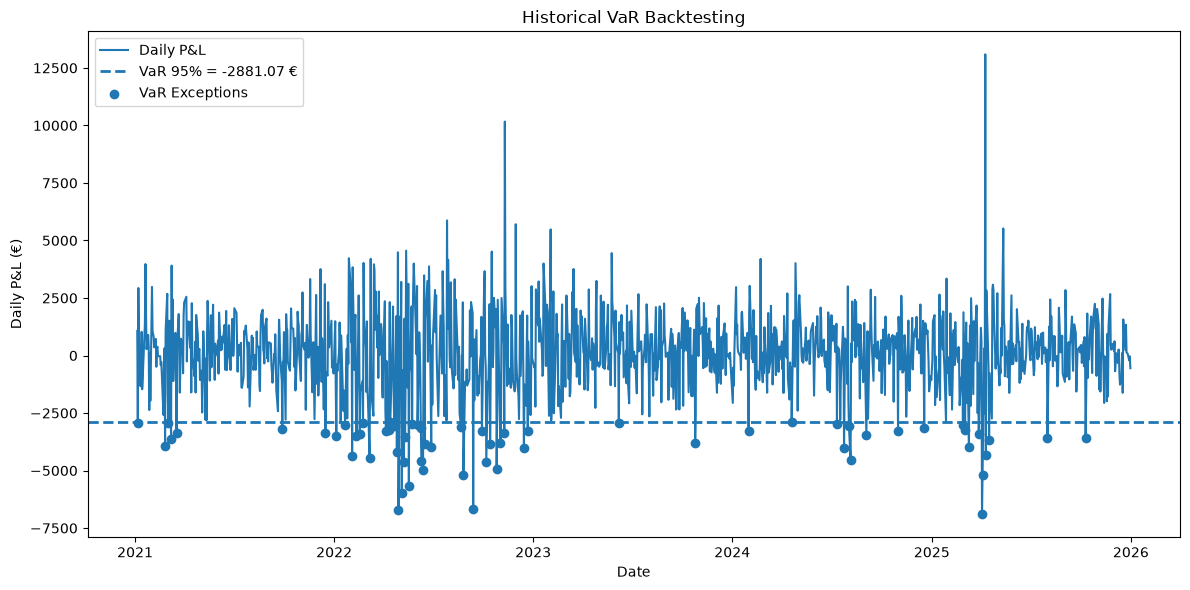

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_pnl.index,
    portfolio_pnl,
    label="Daily P&L"
)

plt.axhline(
    var_threshold,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% = -{var_historical_eur:.2f} €"
)

plt.scatter(
    exceptions.index,
    exceptions.values,
    label="VaR Exceptions"
)

plt.title("Historical VaR Backtesting")
plt.xlabel("Date")
plt.ylabel("Daily P&L (€)")
plt.legend()

plt.tight_layout()
plt.savefig("../images/var_backtesting.png", dpi=300)
plt.show()